**지역 축제가 지역 관광 소비에 끼치는 영향에 대한 분석 **

0. 데이터 불러오기 및 전처리
1. 비축제기간과 축제기간의 관광 소비 증가율 비교 시각화
2. 비축제기간과 축제기간의 외부방문자 증가율 비교 시각화 
3. 축제의 진행 일수에 따른 관광 소비 증가율
4. 축제의 진행 일수에 따른 외부 방문자 증가율
5. 총강수량와 관광소비 증가율
6. 평균기온와 관광소비 증가율

0. 데이터 불러오기 및 전처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df_festival = pd.read_csv("충청도_문화축제.csv")
df_index = pd.read_csv("문화관광축제_주요_지표.csv")
df_weather = pd.read_csv("문화관광축제_날씨.csv")

In [3]:
df_festival["축제시작일자"] = pd.to_datetime(df_festival["축제시작일자"])
df_festival["축제종료일자"] = pd.to_datetime(df_festival["축제종료일자"])

df_weather["일시"] = pd.to_datetime(df_weather["일시"])

In [4]:
df_weather['일강수량(mm)'] = df_weather['일강수량(mm)'].replace(np.nan, 0)

weather_group = df_weather.groupby('축제명')

df_weather_summary = pd.DataFrame()
df_weather_summary['평균기온'] = weather_group['평균기온(°C)'].mean().round(2)
df_weather_summary['총강수량'] = weather_group['일강수량(mm)'].sum()
df_weather_summary['축제진행일수'] = weather_group['일시'].count()

df_weather_summary = df_weather_summary.reset_index()

1. 비축제기간과 축제기간의 관광 소비 증가율 비교 시각화

In [5]:
df_tour = df_index[df_index["구분명"] == "관광소비"]

pivot = df_tour.pivot(
    index="축제명",
    columns="그룹명",
    values="지표값"
)

pivot["증가율"] = (
    (pivot["축제기간"] - pivot["비축제기간"])
    / pivot["비축제기간"]
) * 100

print(" 축제 개최에 따른 주변 상권 관광소비 증가율 결과 ")

pivot = pivot.sort_values(by="증가율", ascending=False)

pivot.columns.name = None
display(pivot.round(2))

 축제 개최에 따른 주변 상권 관광소비 증가율 결과 


,비축제기간,축제기간,증가율
축제명,,,
2025 논산딸기축제,0.46,0.73,56.77
제28회 보령머드축제,0.29,0.42,48.60
제56회 영동난계국악축제,0.48,0.56,16.77
천안흥타령춤축제,0.69,0.70,1.15
제26회 음성품바축제,0.72,0.72,0.55
2025 괴산고추축제,0.61,0.56,-8.32


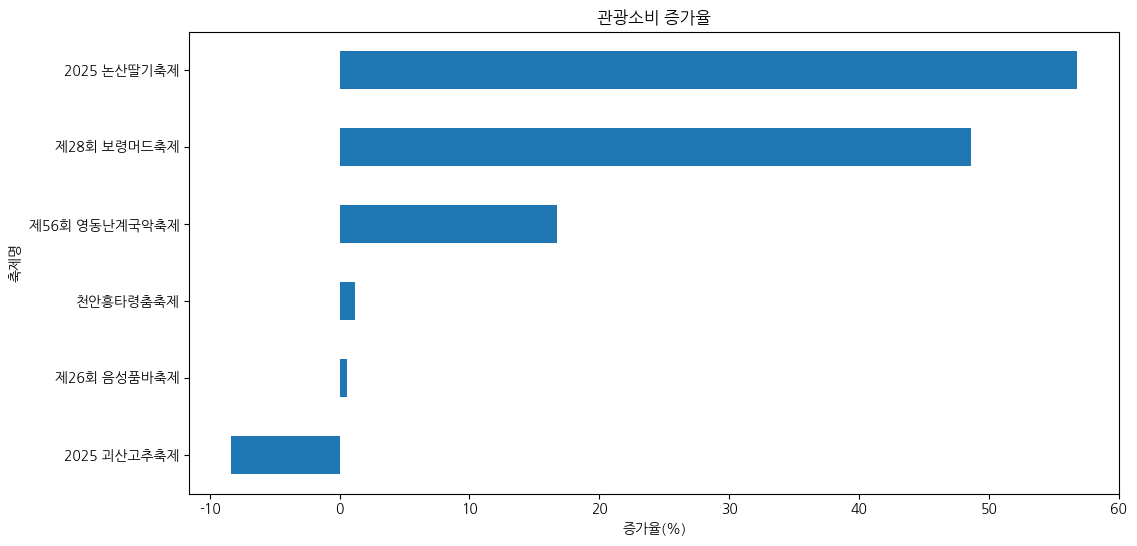

In [6]:
plt.figure(figsize=(12,6))

pivot["증가율"].sort_values().plot(kind="barh")

plt.title("관광소비 증가율")
plt.xlabel("증가율(%)")

plt.show()

논산딸기축제(56.77%), 보령머드축제(48.60%) 등 일부 축제에서 축제기간 관광소비가 비축제기간 대비 큰 폭으로 증가함 반면 괴산고추축제(-8.32%)는 축제기간 관광소비가 비축제기간보다 오히려 감소함
축제 규모 및 인지도에 따라 관광소비 증가율에 편차가 존재하는 것으로 보임

2. 비축제기간과 축제기간의 외부방문자 증가율 비교 시각화 

In [7]:
visitor = df_index[df_index["구분명"] == "외부방문자 유입"]

pivot_v = visitor.pivot(
    index="축제명",
    columns="그룹명",
    values="지표값"
)

pivot_v["증가율"] = (
    (pivot_v["축제기간"] - pivot_v["비축제기간"])
    / pivot_v["비축제기간"]
) * 100

print(" 축제 개최에 따른 주변 상권 외부방문자 증가율 결과 ")

pivot_v = pivot_v.sort_values(by="증가율", ascending=False)

pivot_v.columns.name = None
display(pivot_v.round(2))

 축제 개최에 따른 주변 상권 외부방문자 증가율 결과 


,비축제기간,축제기간,증가율
축제명,,,
제26회 음성품바축제,0.35,0.69,94.90
제28회 보령머드축제,0.29,0.47,59.73
천안흥타령춤축제,0.51,0.78,54.03
2025 논산딸기축제,0.32,0.47,49.21
제56회 영동난계국악축제,0.26,0.38,48.06
2025 괴산고추축제,0.42,0.59,40.91


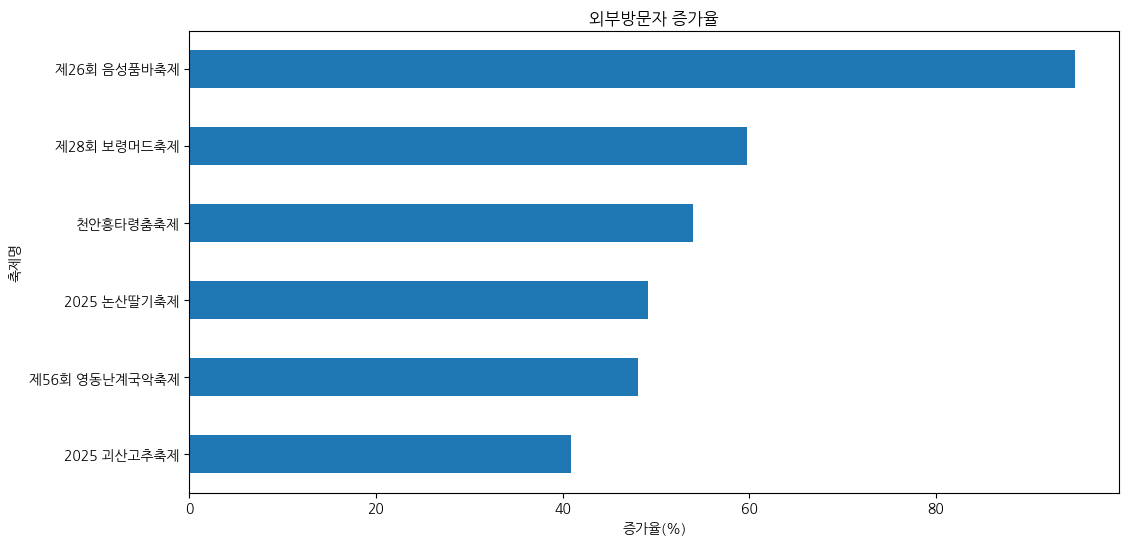

In [8]:
pivot_v["증가율"].sort_values().plot(
    kind="barh",
    figsize=(12,6)
)

plt.title("외부방문자 증가율")
plt.xlabel("증가율(%)")

plt.show()

전체 6개 축제 모두 축제기간에 외부방문자가 비축제기간 대비 증가하였으며 음성품바축제(94.90%)의 증가율이 가장 높음 논산딸기축제(49.21%), 보령머드축제(59.73%), 천안흥타령춤축제(54.03%) 등도 50% 안팎의 높은 외부방문자 증가율을 기록함
외부방문자 증가율은 관광소비 증가율보다 전반적으로 높은 수준을 보임 그러나 괴산고추축제와 같이 방문자 유입은 되지만 소비 전환이 충분하지 않은 경우가 있음

3. 축제의 진행 일수에 따른 관광 소비 증가율

In [9]:
df_festival_on = df_index[df_index['그룹명'] == '축제기간']
df_festival_off = df_index[df_index['그룹명'] == '비축제기간']

df_merge = pd.merge(df_festival_on, df_festival_off, on=['축제명', '구분명'], suffixes=('_축제기', '_비축제기'))

df_merge['축제효과'] = df_merge['지표값_축제기'] - df_merge['지표값_비축제기']

df_merge['증가율(%)'] = (((df_merge['지표값_축제기'] - df_merge['지표값_비축제기']) / df_merge['지표값_비축제기']) * 100).round(2)

df_visitor_effect = df_merge[df_merge['구분명'] == '외부방문자 유입'][['축제명', '축제효과', '증가율(%)']].rename(
    columns={'축제효과': '외부방문자_증가량', '증가율(%)': '외부방문자_증가율'}
)
df_money_effect = df_merge[df_merge['구분명'] == '관광소비'][['축제명', '축제효과', '증가율(%)']].rename(
    columns={'축제효과': '관광소비_증가량', '증가율(%)': '관광소비_증가율'}
)

df_final = pd.merge(df_weather_summary, df_visitor_effect, on='축제명')
df_final = pd.merge(df_final, df_money_effect, on='축제명')

df_final

,축제명,평균기온,총강수량,축제진행일수,외부방문자_증가량,외부방문자_증가율,관광소비_증가량,관광소비_증가율
0,2025 괴산고추축제,26.32,3.1,4,0.171,40.91,-0.051,-8.32
1,2025 논산딸기축제,6.78,1.5,4,0.155,49.21,0.264,56.77
2,제26회 음성품바축제,23.08,19.3,5,0.335,94.90,0.004,0.55
3,제28회 보령머드축제,28.22,107.6,17,0.175,59.73,0.139,48.60
4,제56회 영동난계국악축제,19.99,214.8,30,0.124,48.06,0.081,16.77
5,천안흥타령춤축제,20.72,51.6,5,0.275,54.03,0.008,1.15


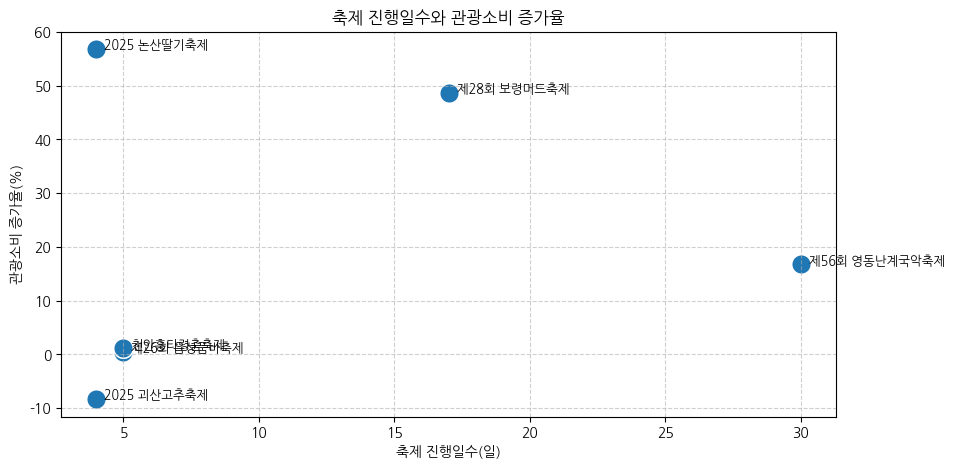

In [10]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_final,
    x='축제진행일수',
    y='관광소비_증가율',
    s=200
)

for i in range(len(df_final)):
    plt.text(
        df_final['축제진행일수'].iloc[i] + 0.3,
        df_final['관광소비_증가율'].iloc[i],
        df_final['축제명'].iloc[i],
        fontsize=9
    )

plt.title('축제 진행일수와 관광소비 증가율')
plt.xlabel('축제 진행일수(일)')
plt.ylabel('관광소비 증가율(%)')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

축제 진행일수와 관광소비 증가율 사이에 뚜렷한 선형 관계는 확인되지 않는 것으로 보임
보령머드축제(17일, +48.60%)와 영동난계국악축제(30일, +16.77%)를 비교하면, 일수가 더 길다고 해서 관광소비 증가율이 높아지지 않음을 시사함
또한 4~5일 단기 축제 중에서도 논산딸기축제(+56.77%)처럼 높은 소비 증가율을 보이는 사례가 있음

4. 축제의 진행 일수에 따른 외부 방문자 증가율

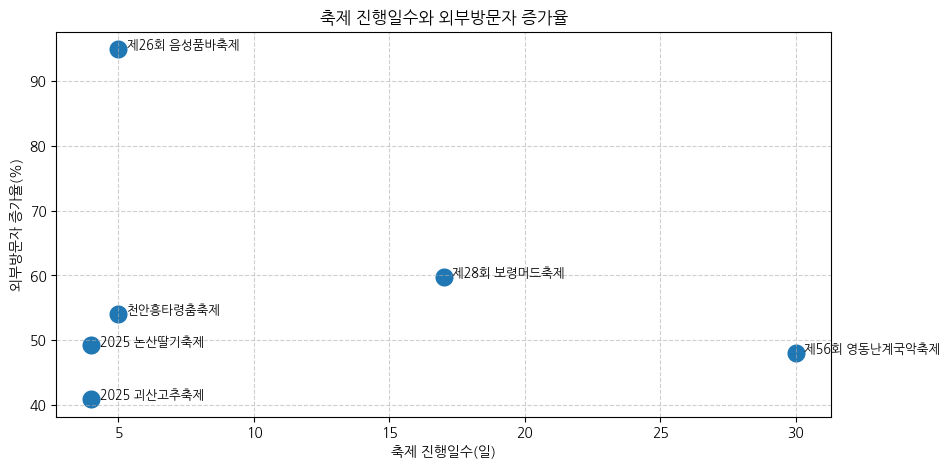

In [11]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_final,
    x='축제진행일수',
    y='외부방문자_증가율',
    s=200
)

for i in range(len(df_final)):
    plt.text(
        df_final['축제진행일수'].iloc[i] + 0.3,
        df_final['외부방문자_증가율'].iloc[i],
        df_final['축제명'].iloc[i],
        fontsize=9
    )

plt.title('축제 진행일수와 외부방문자 증가율')
plt.xlabel('축제 진행일수(일)')
plt.ylabel('외부방문자 증가율(%)')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

5일 규모의 음성품바축제가 94.90%로 가장 높은 외부방문자 증가율을 기록하여, 단기간에도 집중 집객이 가능함을 보여줌
30일의 영동난계국악축제는 외부방문자 증가율이 48.06%로 상대적으로 낮아, 장기 개최가 반드시 방문자 유입에 유리하지 않을 수 있음
축제 진행일수가 길수록 외부방문자 증가율이 높아지는 경향은 나타나지 않는 것으로 보임

5. 총강수량와 관광소비 증가율

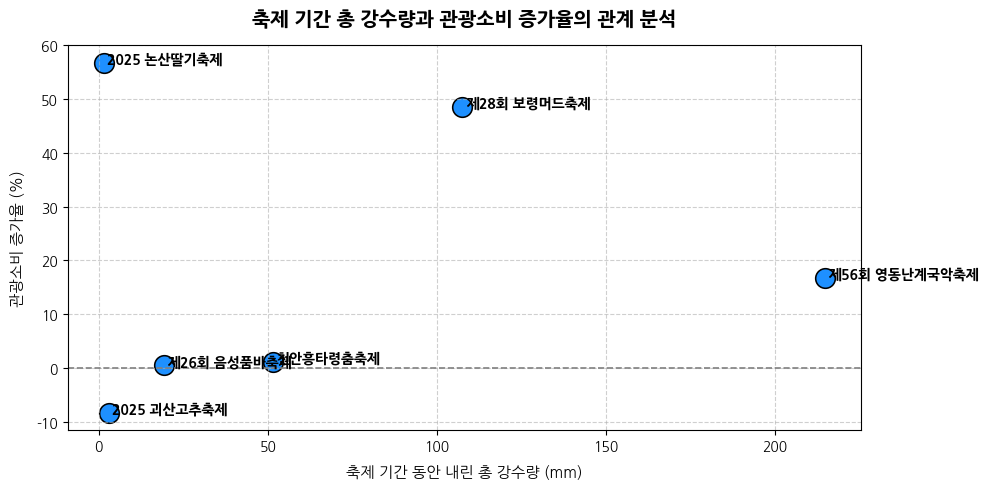

In [12]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=df_final, x='총강수량', y='관광소비_증가율', s=200, color='dodgerblue', edgecolor='black')

for i in range(len(df_final)):
    x_pos = df_final['총강수량'].iloc[i] + 1
    y_pos = df_final['관광소비_증가율'].iloc[i] 
        
    plt.text(x_pos, y_pos, df_final['축제명'].iloc[i], fontsize=10, fontweight='bold')

plt.axhline(0, color='gray', linewidth=1.2, linestyle='--')

plt.title('축제 기간 총 강수량과 관광소비 증가율의 관계 분석', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('축제 기간 동안 내린 총 강수량 (mm)', fontsize=11, labelpad=8)
plt.ylabel('관광소비 증가율 (%)', fontsize=11, labelpad=8) 
plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

강수량이 적은 축제(논산딸기축제 1.5mm, +56.77% & 보령머드축제 107.6mm, +48.60%)와 강수량이 많은 축제(영동난계국악축제 214.8mm, +16.77%) 간 소비 증가율 차이가 존재함
총강수량이 증가할수록 관광소비 증가율이 감소하는 경향이 보임 다만 강수량 외에도 축제 성격, 야외 시설 여부 등이 복합적으로 영향을 미칠 것으로 판단됨

6. 평균기온와 관광소비 증가율

In [13]:
weather_summary = (

    df_weather

    .groupby("축제명")

    .agg({

        "평균기온(°C)":"mean",

        "일강수량(mm)":"sum"

    })

    .reset_index()

)



result = pd.merge(

    pivot.reset_index(),

    weather_summary,

)

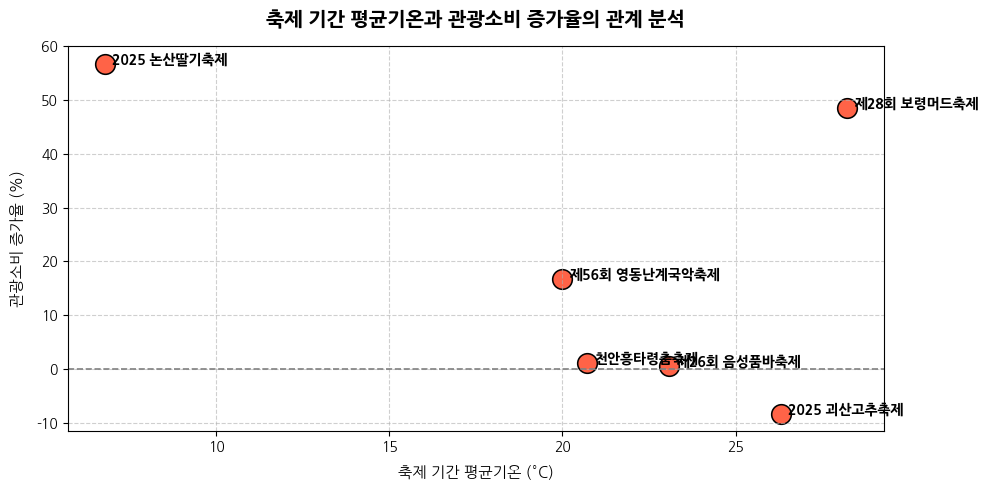

In [14]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=result,
    x='평균기온(°C)',
    y='증가율',
    s=200,
    color='tomato',
    edgecolor='black'
)

for i in range(len(result)):
    x_pos = result['평균기온(°C)'].iloc[i] + 0.2
    y_pos = result['증가율'].iloc[i]

    plt.text(
        x_pos,
        y_pos,
        result['축제명'].iloc[i],
        fontsize=10,
        fontweight='bold'
    )

plt.axhline(
    0,
    color='gray',
    linewidth=1.2,
    linestyle='--'
)

plt.title(
    '축제 기간 평균기온과 관광소비 증가율의 관계 분석',
    fontsize=14,
    pad=15,
    fontweight='bold'
)

plt.xlabel(
    '축제 기간 평균기온 (°C)',
    fontsize=11,
    labelpad=8
)

plt.ylabel(
    '관광소비 증가율 (%)',
    fontsize=11,
    labelpad=8
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

평균기온과 관광소비 증가율 사이에 일관된 관계는 나타나지 않음
저온(논산딸기축제 6.78°C, +56.77%)과 고온(보령머드축제 28.22°C, +48.60%) 모두 높은 증가율을 보여, 기온보다 축제 브랜드 및 체험 요소가 소비에 더 큰 영향을 미치는 것으로 보임 또한 중간 기온대(천안흥타령춤축제 20.72°C, +1.15%)에서 낮은 증가율이 나타난 사례도 있어 기온 단독으로는 관광소비를 설명하기 어려운 것으로 보임